In [3]:
import pandas as pd
import numpy as np


In [4]:
import os
print(os.getcwd())        # confirms which folder Python is looking in
print(os.listdir()) 

C:\Users\Anuja
['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.mcp-auth', '.VirtualBox', '.vscode', '.vscode-R', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'Assignment_1.ipynb', 'Auto.csv', 'BFSI_PROJECT_EDA.ipynb', 'Contacts', 'Cookies', 'cs-training.csv', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'miniconda3', 'modified_auto.csv', 'modified_auto.xlsx', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{12670aa4-945c-11f0-9706-caef5c43abed}.TM.blf', 'NTUSER.DAT{12670aa4-945c-11f0-9706-caef5c43abed}.TM.blf.cnpf', 'NTUSER.DAT{12670aa4-945c-11f0-9706-caef5c43abed}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{12670aa4-945c-11f0-9706-caef5c43abed}.TMContainer00000000000000000001.regtrans-ms.cnpf', 'NTUSER.DAT{12670aa4-945c-11f0-9706-caef5c43abed}.TMContainer00000000000000000002.regtrans-ms

In [5]:
df = pd.read_csv('cs-training.csv')

In [6]:
# 1. Drop unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [9]:
# 2. Fill missing MonthlyIncome with median
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())


In [12]:
# 3. Fill missing NumberOfDependents with 0
# Explicit reassignment
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)


In [14]:
# 4. Cap RevolvingUtilization outliers at 1.0 (values > 1 = data error)
df['RevolvingUtilizationOfUnsecuredLines'] = df[
    'RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

In [15]:
# 5. Cap DebtRatio outliers at 99th percentile
cap = df['DebtRatio'].quantile(0.99)
df['DebtRatio'] = df['DebtRatio'].clip(upper=cap)

In [16]:
# 6. Create risk buckets for age (for Power BI slicers)
df['AgeGroup'] = pd.cut(df['age'],
    bins=[0,30,40,50,60,100],
    labels=['<30','30–40','40–50','50–60','60+'])

In [17]:
# 7. Create credit utilisation band
df['UtilBand'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'],
    bins=[0,0.3,0.6,0.8,1.0],
    labels=['Low (0–30%)','Medium (30–60%)','High (60–80%)','Very High (80%+)'])

In [19]:
# 8. Rename target column for clarity
df.rename(columns={'SeriousDlqin2yrs': 'DefaultFlag'}, inplace=True)

In [20]:
df.to_csv('clean_credit.csv', index=False)
print(df.shape, df['DefaultFlag'].value_counts())

(150000, 13) DefaultFlag
0    139974
1     10026
Name: count, dtype: int64


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Portfolio-quality style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F8F6",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

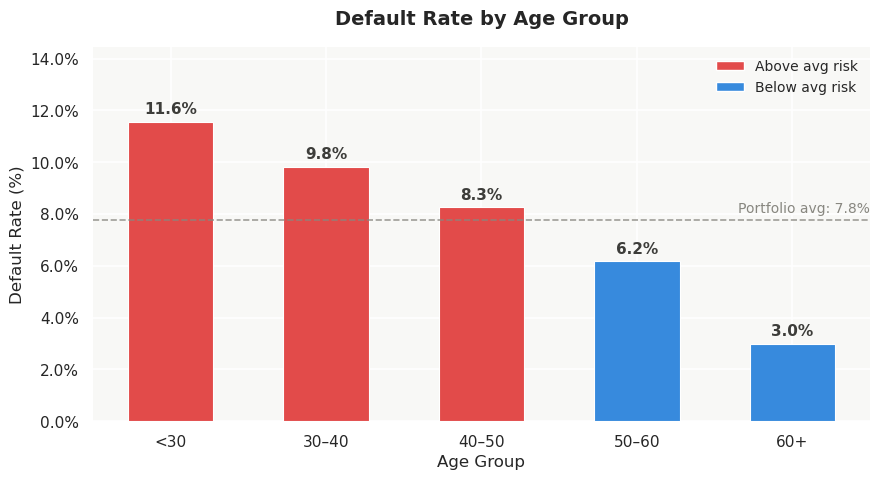

Highest risk group: <30


In [22]:
# Chart 1: Default rate by age group
default_by_age = (
    df.groupby('AgeGroup', observed=True)['DefaultFlag']
    .mean()
    .reset_index()
    .rename(columns={'DefaultFlag': 'DefaultRate'})
)
default_by_age['DefaultRatePct'] = default_by_age['DefaultRate'] * 100

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    default_by_age['AgeGroup'].astype(str),
    default_by_age['DefaultRatePct'],
    color=['#E24B4A' if v > default_by_age['DefaultRatePct'].mean()
           else '#378ADD'
           for v in default_by_age['DefaultRatePct']],
    width=0.55,
    edgecolor='white',
    linewidth=0.8
)

# Add value labels on bars
for bar, val in zip(bars, default_by_age['DefaultRatePct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='#3d3d3a'
    )

# Portfolio average reference line
avg = default_by_age['DefaultRatePct'].mean()
ax.axhline(avg, color='#888780', linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(len(default_by_age) - 0.5, avg + 0.3,
        f'Portfolio avg: {avg:.1f}%',
        color='#888780', fontsize=10, ha='right')

ax.set_title('Default Rate by Age Group', pad=16)
ax.set_xlabel('Age Group')
ax.set_ylabel('Default Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_ylim(0, default_by_age['DefaultRatePct'].max() * 1.25)

# Legend for colour meaning
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='Above avg risk'),
    Patch(facecolor='#378ADD', label='Below avg risk')
]
ax.legend(handles=legend_elements, loc='upper right',
          frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('chart1_default_rate_by_age.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"Highest risk group: {default_by_age.loc[default_by_age['DefaultRatePct'].idxmax(), 'AgeGroup']}")

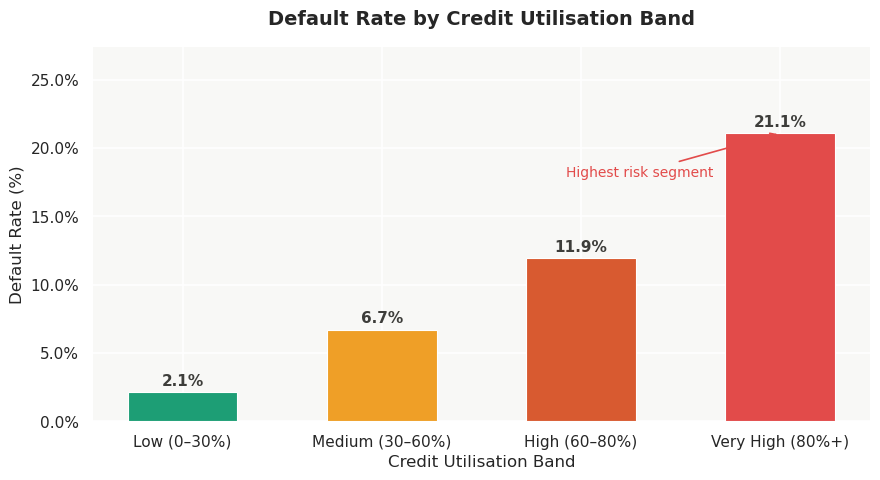

Low (0–30%): 2.1% default rate
Medium (30–60%): 6.7% default rate
High (60–80%): 11.9% default rate
Very High (80%+): 21.1% default rate


In [23]:
# Chart 2: Default rate by utilisation band
default_by_util = (
    df.groupby('UtilBand', observed=True)['DefaultFlag']
    .mean()
    .reset_index()
    .rename(columns={'DefaultFlag': 'DefaultRate'})
)
default_by_util['DefaultRatePct'] = default_by_util['DefaultRate'] * 100

# Custom colour gradient from safe to danger
util_colors = ['#1D9E75', '#EF9F27', '#D85A30', '#E24B4A']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    default_by_util['UtilBand'].astype(str),
    default_by_util['DefaultRatePct'],
    color=util_colors[:len(default_by_util)],
    width=0.55,
    edgecolor='white',
    linewidth=0.8
)

# Value labels
for bar, val in zip(bars, default_by_util['DefaultRatePct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='#3d3d3a'
    )

# Annotate the highest risk bar
max_idx = default_by_util['DefaultRatePct'].idxmax()
max_bar = bars[max_idx]
ax.annotate(
    'Highest risk segment',
    xy=(max_bar.get_x() + max_bar.get_width() / 2,
        default_by_util['DefaultRatePct'].max()),
    xytext=(max_bar.get_x() - 0.8,
            default_by_util['DefaultRatePct'].max() * 0.85),
    fontsize=10, color='#E24B4A',
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.2)
)

ax.set_title('Default Rate by Credit Utilisation Band', pad=16)
ax.set_xlabel('Credit Utilisation Band')
ax.set_ylabel('Default Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_ylim(0, default_by_util['DefaultRatePct'].max() * 1.3)

plt.tight_layout()
plt.savefig('chart2_default_rate_by_utilband.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

# Print the finding — copy this as a README insight
for _, row in default_by_util.iterrows():
    print(f"{row['UtilBand']}: {row['DefaultRatePct']:.1f}% default rate")

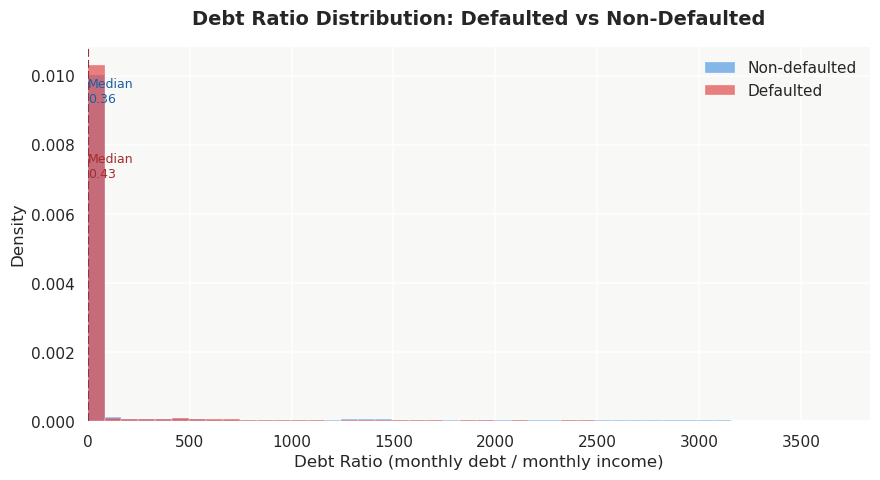

Median DebtRatio — Non-defaulted: 0.363
Median DebtRatio — Defaulted:     0.428


In [24]:
# Chart 3: DebtRatio distribution by default status
fig, ax = plt.subplots(figsize=(9, 5))

defaulted = df[df['DefaultFlag'] == 1]['DebtRatio']
non_defaulted = df[df['DefaultFlag'] == 0]['DebtRatio']

ax.hist(non_defaulted, bins=60, alpha=0.6,
        color='#378ADD', label='Non-defaulted',
        edgecolor='white', linewidth=0.3,
        density=True)

ax.hist(defaulted, bins=60, alpha=0.7,
        color='#E24B4A', label='Defaulted',
        edgecolor='white', linewidth=0.3,
        density=True)

# Median lines
ax.axvline(non_defaulted.median(), color='#185FA5',
           linestyle='--', linewidth=1.5, alpha=0.9)
ax.axvline(defaulted.median(), color='#A32D2D',
           linestyle='--', linewidth=1.5, alpha=0.9)

ax.text(non_defaulted.median() + 0.01, ax.get_ylim()[1] * 0.85,
        f'Median\n{non_defaulted.median():.2f}',
        color='#185FA5', fontsize=9, ha='left')
ax.text(defaulted.median() + 0.01, ax.get_ylim()[1] * 0.65,
        f'Median\n{defaulted.median():.2f}',
        color='#A32D2D', fontsize=9, ha='left')

ax.set_title('Debt Ratio Distribution: Defaulted vs Non-Defaulted', pad=16)
ax.set_xlabel('Debt Ratio (monthly debt / monthly income)')
ax.set_ylabel('Density')
ax.set_xlim(0, df['DebtRatio'].quantile(0.98))
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig('chart3_debtratio_distribution.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"Median DebtRatio — Non-defaulted: {non_defaulted.median():.3f}")
print(f"Median DebtRatio — Defaulted:     {defaulted.median():.3f}")

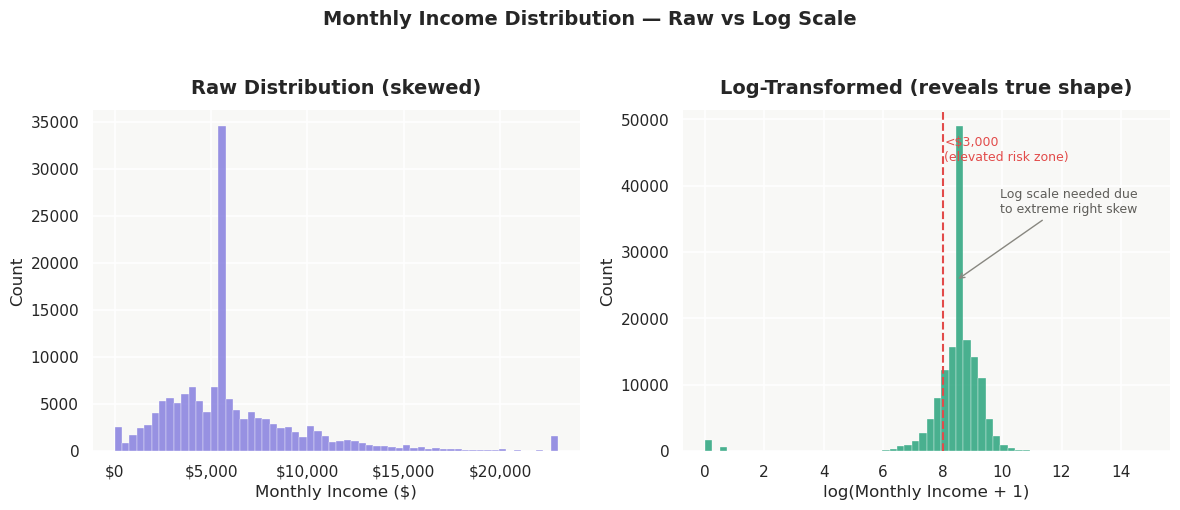

Income median: $5,400
Income mean:   $6,418
Skew:          127.12 (>1 = heavily right-skewed)


In [25]:
# Chart 4: MonthlyIncome distribution with log scale
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: raw distribution (shows the skew problem)
axes[0].hist(df['MonthlyIncome'].clip(upper=df['MonthlyIncome'].quantile(0.99)),
             bins=60, color='#7F77DD', alpha=0.8,
             edgecolor='white', linewidth=0.3)
axes[0].set_title('Raw Distribution (skewed)', pad=12)
axes[0].set_xlabel('Monthly Income ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Right: log scale (reveals the true shape)
log_income = np.log1p(df['MonthlyIncome'])
axes[1].hist(log_income, bins=60, color='#1D9E75', alpha=0.8,
             edgecolor='white', linewidth=0.3)

# Shade the low-income zone (potential risk indicator)
low_income_threshold = np.log1p(3000)
axes[1].axvline(low_income_threshold, color='#E24B4A',
                linestyle='--', linewidth=1.5)
axes[1].text(low_income_threshold + 0.05,
             axes[1].get_ylim()[1] * 0.85,
             '<$3,000\n(elevated risk zone)',
             color='#E24B4A', fontsize=9)

axes[1].set_title('Log-Transformed (reveals true shape)', pad=12)
axes[1].set_xlabel('log(Monthly Income + 1)')
axes[1].set_ylabel('Count')

# Add annotation explaining why log scale
axes[1].annotate(
    'Log scale needed due\nto extreme right skew',
    xy=(log_income.mean(), axes[1].get_ylim()[1] * 0.5),
    xytext=(log_income.mean() + 1.5, axes[1].get_ylim()[1] * 0.7),
    fontsize=9, color='#5F5E5A',
    arrowprops=dict(arrowstyle='->', color='#888780', lw=1)
)

fig.suptitle('Monthly Income Distribution — Raw vs Log Scale',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart4_monthlyincome_distribution.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"Income median: ${df['MonthlyIncome'].median():,.0f}")
print(f"Income mean:   ${df['MonthlyIncome'].mean():,.0f}")
print(f"Skew:          {df['MonthlyIncome'].skew():.2f} (>1 = heavily right-skewed)")